# CIFAR-10 Backbone Comparison — Results Analysis

ResNet-50 vs EfficientNet-B3 vs ConvNeXt-T transfer learning results. This notebook reads `results/*.json` files and produces a summary table and charts. **All three models are complete.**

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results")
result_files = sorted(RESULTS_DIR.glob("*.json"))

results = {}
for f in result_files:
    with open(f) as fh:
        results[f.stem] = json.load(fh)

print(f"Results found: {list(results.keys())}")

Results found: ['convnext_tiny', 'efficientnet_b3', 'resnet50']


## Summary Table

In [2]:
rows = []
for name, r in results.items():
    epoch_times = r["history"]["epoch_time_sec"]
    rows.append({
        "model": r["model"],
        "num_params": r["num_params"],
        "best_val_acc": r["best_val_acc"],
        "final_val_acc": r["final_val_acc"],
        "total_train_time_min": r["total_train_time_sec"] / 60,
        "avg_epoch_time_sec": sum(epoch_times) / len(epoch_times),
        "median_epoch_time_sec": sorted(epoch_times)[len(epoch_times) // 2],
    })

summary = pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
summary

,model,num_params,best_val_acc,final_val_acc,total_train_time_min,avg_epoch_time_sec,median_epoch_time_sec
0,efficientnet_b3,10711602,0.9819,0.9809,158.873477,381.230182,353.191556
1,convnext_tiny,27827818,0.9786,0.9786,164.255366,394.095263,376.454605
2,resnet50,23528522,0.9734,0.9725,209.675161,503.117383,312.121719


## Chart: Best Val Accuracy Bar Chart (for Medium)

The early "proof" visual for the article — compares the best validation accuracy of the three models.

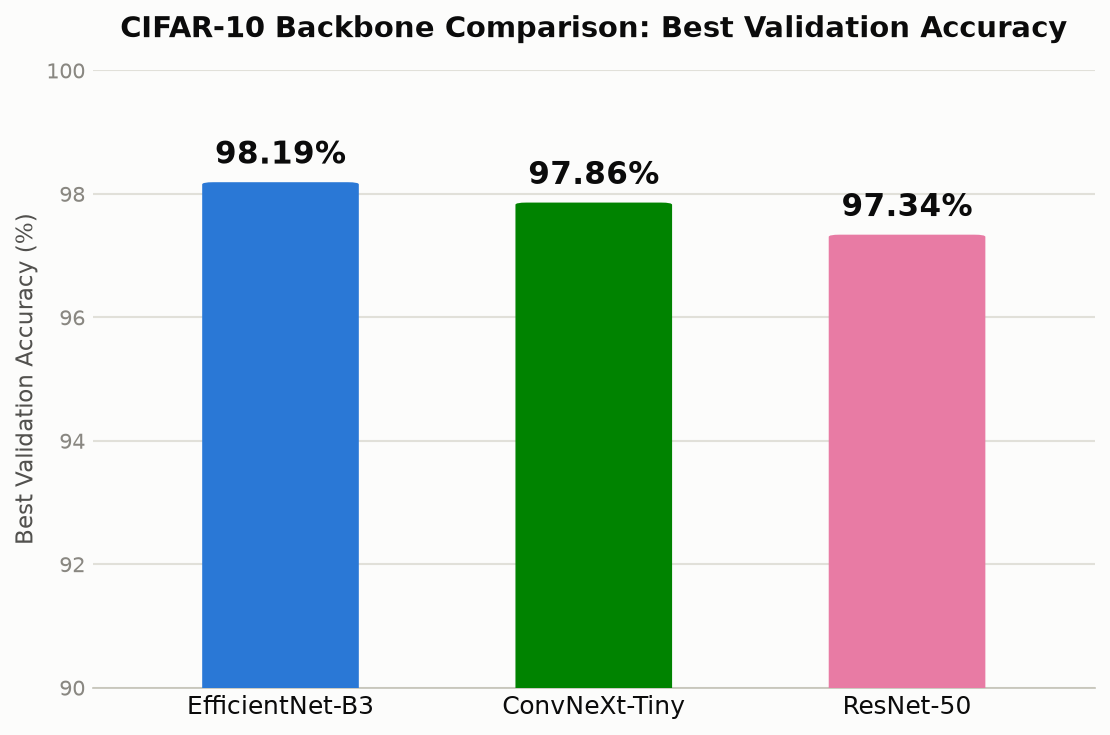

In [3]:
from matplotlib.patches import FancyBboxPatch

model_display = {"resnet50": "ResNet-50", "efficientnet_b3": "EfficientNet-B3", "convnext_tiny": "ConvNeXt-Tiny"}
CATEGORICAL = ["#2a78d6", "#008300", "#e87ba4"]  # fixed-order categorical slots 1/2/3
SURFACE, PRIMARY_INK, SECONDARY_INK, MUTED, GRID, BASELINE = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7",
)

labels = [model_display[m] for m in summary["model"]]
accs = (summary["best_val_acc"] * 100).tolist()
colors = CATEGORICAL[: len(labels)]

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

for i, (acc, color) in enumerate(zip(accs, colors)):
    ax.add_patch(FancyBboxPatch((i - 0.25, 0), 0.5, acc, boxstyle="round,pad=0,rounding_size=0.035",
                                 linewidth=0, facecolor=color, zorder=3, mutation_aspect=1))
    ax.text(i, acc + 0.18, f"{acc:.2f}%", ha="center", va="bottom",
            fontsize=15, fontweight="bold", color=PRIMARY_INK)

ax.set_xlim(-0.6, len(labels) - 0.4)
ax.set_ylim(90, 100)
ax.set_yticks([90, 92, 94, 96, 98, 100])
ax.set_ylabel("Best Validation Accuracy (%)", fontsize=11, color=SECONDARY_INK)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=12, color=PRIMARY_INK)
ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(axis="y", colors=MUTED, labelsize=10, length=0)
ax.tick_params(axis="x", colors=PRIMARY_INK, length=0)
ax.set_title("CIFAR-10 Backbone Comparison: Best Validation Accuracy",
             fontsize=14, fontweight="bold", color=PRIMARY_INK, pad=16)

plt.tight_layout()
plt.savefig("accuracy_barchart.png", dpi=300, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## ResNet-50 — Detailed Results

| Metric | Value |
|---|---|
| Parameter count | 23,528,522 (~23.5M) |
| Best val_acc | **97.34%** (epoch 23) |
| Final epoch val_acc | 97.25% (epoch 25) |
| Total training time | 12,580s (~209.7 min / ~3.5 hours) |
| Average epoch time | ~503s (includes 2 anomalously slow epochs; median ~340s is more representative) |
| Batch size | 64 |

## EfficientNet-B3 — Detailed Results

| Metric | Value |
|---|---|
| Parameter count | 10,711,602 (~10.7M) |
| Best val_acc | **98.19%** (epoch 22) |
| Final epoch val_acc | 98.09% (epoch 25) |
| Total training time | 9,532s (~158.9 min / ~2.6 hours) |
| Average epoch time | ~381s (median ~353s) |
| Batch size | 32 |

### Comparison: ResNet-50 vs EfficientNet-B3

- **Accuracy**: EfficientNet-B3 beat ResNet-50 by **0.85 points** (98.19% vs 97.34%) — for transfer learning of ImageNet weights on this task, the EfficientNet architecture (compound scaling + MBConv blocks) generalizes slightly better.
- **Parameter efficiency**: EfficientNet-B3 reached higher accuracy with only **~45%** of ResNet-50's parameters (10.7M vs 23.5M) — far more parameter-efficient.
- **Training time**: Despite a smaller batch size (32 vs 64, due to VRAM constraints), EfficientNet-B3 finished **faster** overall (~2.6 hours vs ~3.5 hours) — mostly because of two anomalously slow epochs in the ResNet-50 run (epochs 14 and 19, likely a background system resource conflict); median epoch time actually shows ResNet-50 is slightly faster per step (312s vs 353s).
- **Convergence**: EfficientNet-B3's val_acc curve is less noisy and plateaus around epoch 20; ResNet-50 kept improving until epoch 22-23.

## ConvNeXt-Tiny — Detailed Results

| Metric | Value |
|---|---|
| Parameter count | 27,827,818 (~27.8M) |
| Best val_acc | **97.86%** (epoch 25 — the final epoch, still improving) |
| Final epoch val_acc | 97.86% |
| Total training time | 9,855s (~164.3 min / ~2.7 hours) |
| Average epoch time | ~394s (median ~376s) |
| Batch size | 32 |

ConvNeXt-Tiny is the largest of the three models (27.8M parameters) but beat ResNet-50 on accuracy (97.86% vs 97.34%), landing just behind EfficientNet-B3 (98.19%). Notably, its best val_acc occurred right at the **final epoch** (25/25) — the curve was still climbing, meaning the model hadn't fully plateaued. With more epochs, ConvNeXt-Tiny could plausibly close the gap with, or surpass, EfficientNet-B3.

### Live wandb Records (metrics + GPU utilization charts)

Live metric curves and GPU utilization/power/memory charts (system monitoring tab) for every run are viewable on the wandb project:

- **Project (all runs)**: https://wandb.ai/sumeyyesaray478-mu-la-s-tk-ko-man-niversitesi/backbone-comparison
- **ResNet-50 run**: https://wandb.ai/sumeyyesaray478-mu-la-s-tk-ko-man-niversitesi/backbone-comparison/runs/6qlg1y9i (runtime 3h29m47s)
- **EfficientNet-B3 run**: https://wandb.ai/sumeyyesaray478-mu-la-s-tk-ko-man-niversitesi/backbone-comparison/runs/dde3bt5j (runtime 2h38m57s)
- **ConvNeXt-Tiny run**: https://wandb.ai/sumeyyesaray478-mu-la-s-tk-ko-man-niversitesi/backbone-comparison/runs/1guf14ce (runtime 2h44m23s)

The run page's **System** tab shows GPU Memory/SM Clock, Power Usage (W/%), and GPU Memory Allocated charts — the real usage pattern on an RTX 3050 Laptop (4GB VRAM), including the periodic per-batch load spikes. wandb's "runtime" field is wall-clock time; some restarts caused by the machine sleeping/losing connectivity aren't included in that figure — `total_train_time_sec` (summary table below) is the more reliable reference for actual training time.

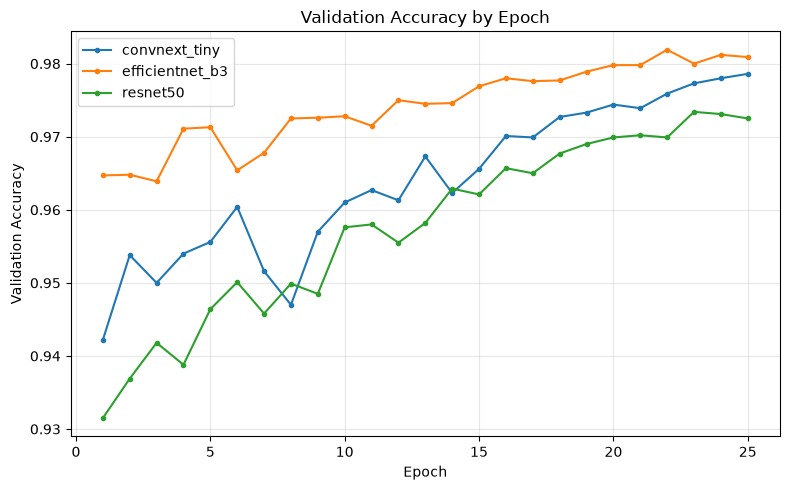

In [4]:
def plot_metric(results, metric, ylabel, title):
    plt.figure(figsize=(8, 5))
    for name, r in results.items():
        plt.plot(range(1, len(r["history"][metric]) + 1), r["history"][metric], label=r["model"], marker="o", markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric(results, "val_acc", "Validation Accuracy", "Validation Accuracy by Epoch")

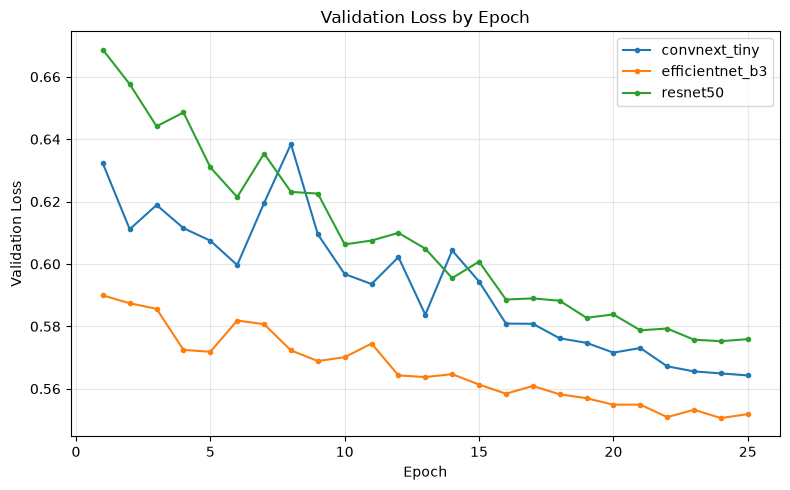

In [5]:
plot_metric(results, "val_loss", "Validation Loss", "Validation Loss by Epoch")

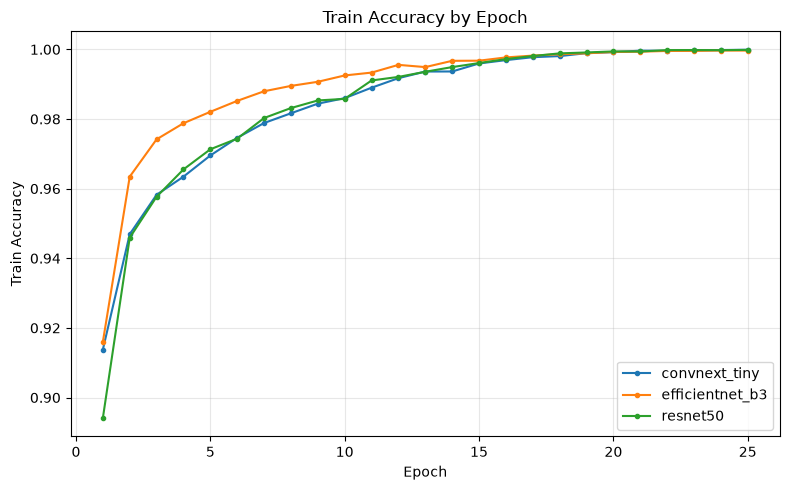

In [6]:
plot_metric(results, "train_acc", "Train Accuracy", "Train Accuracy by Epoch")

## Parameter Count vs Best Val Acc

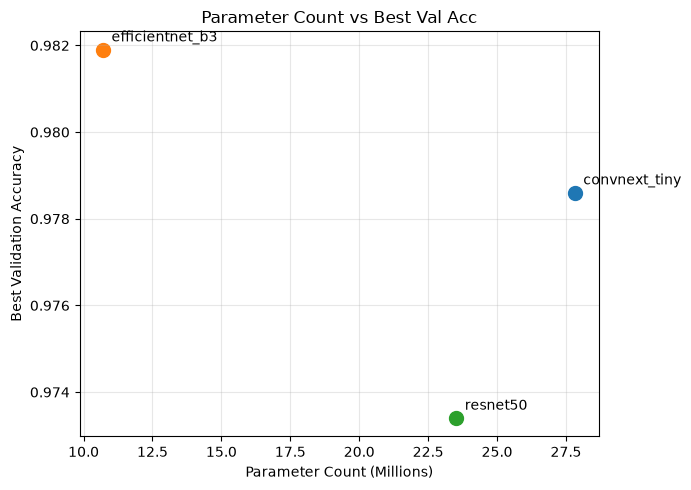

In [7]:
plt.figure(figsize=(7, 5))
for name, r in results.items():
    plt.scatter(r["num_params"] / 1e6, r["best_val_acc"], s=100)
    plt.annotate(r["model"], (r["num_params"] / 1e6, r["best_val_acc"]), textcoords="offset points", xytext=(6, 6))
plt.xlabel("Parameter Count (Millions)")
plt.ylabel("Best Validation Accuracy")
plt.title("Parameter Count vs Best Val Acc")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion: Three-Model Comparison

| Model | Params | Best Val Acc | Total Time | Median Epoch Time | Best Epoch |
|---|---|---|---|---|---|
| **EfficientNet-B3** | 10.7M | **98.19%** | 2.6 hours | 353s | 22/25 |
| ConvNeXt-Tiny | 27.8M | 97.86% | 2.7 hours | 376s | 25/25 (still improving) |
| ResNet-50 | 23.5M | 97.34% | 3.5 hours | 312s | 23/25 |

**Highest accuracy**: EfficientNet-B3, with 98.19% best val_acc, is the strongest of the three — 0.85 points ahead of ResNet-50 and 0.33 points ahead of ConvNeXt-Tiny.

**Fastest to converge**: EfficientNet-B3 was also first to cross 97% val_acc, doing so around epoch 8-9 (ConvNeXt-Tiny around epoch 16-18, ResNet-50 around epoch 21-23). ConvNeXt-Tiny was still climbing at epoch 25 — it hadn't fully converged.

**Most parameter-efficient**: EfficientNet-B3, by a wide margin — it reached the best accuracy using only ~45% of ResNet-50's parameters and ~38% of ConvNeXt-Tiny's. Compound scaling + MBConv block design shows a clear efficiency advantage for transfer learning on CIFAR-10.

**Practical note**: Read the total-training-time comparison with care — the ResNet-50 run hit two anomalously slow epochs (14 and 19, likely a system resource conflict; see the `epoch_time_sec` chart). Looking at median epoch time instead, ResNet-50 is actually the fastest per step (312s); EfficientNet-B3 and ConvNeXt-Tiny take slightly longer per step but need fewer epochs/steps to reach the target.

**Overall recommendation**: In scenarios with limited VRAM (4GB) and limited training time, EfficientNet-B3 is the best-balanced choice of the three — highest accuracy, fewest parameters, and fastest convergence.